# Background Analysis CAR170

## Introduction

Analyze the origin of the apparent excess background contamination on the WFI PRISM images. 

Author: Alejandro S. Borlaff, Pablo M. Sanchez Alarcon - 24 Sept 2026 

## Imports

In [2]:
import rosalia as rs
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.io.votable import parse_single_table
from tqdm import tqdm 

CAR170_db = parse_single_table("Roman_CAR170.xml").to_table() 

# Clean up the table and get the MJD 
visit_start_time = np.zeros(len(CAR170_db))

for i in tqdm(range(len(CAR170_db))):
    try:
        visit_start_time[i] = Time(np.array(CAR170_db["visit_start_time"])[i], format="isot").mjd
    except:
        visit_start_time[i] = np.nan

CAR170_db["mjd"] = visit_start_time
CAR170_db = CAR170_db[:][~np.isnan(visit_start_time)]

100%|██████████| 1890/1890 [00:00<00:00, 16193.73it/s]


In [4]:
# Get the planets 
d_sun = np.zeros(len(CAR170_db))
d_MW  = np.zeros(len(CAR170_db))
mjd  = np.zeros(len(CAR170_db))

from tqdm import tqdm 
mjd_0 = Time(CAR170_db["exposure_start_time"][0], format="isot").mjd

# Aprox location of the Sun and planets from Roman POV for test. 
sso_bodies = rs.sso.get_SS0s_loc_magnitude(observer="Roman", MJD=mjd_0, lambda_ref=1.7*u.um, verbose=False)

for i in tqdm(range(len(CAR170_db))):
    ra_target = CAR170_db["ra"][i]
    dec_target = CAR170_db["dec"][i]

    #print(ra_target)
    #print(dec_target)
    mjd[i] = Time(CAR170_db["exposure_start_time"][i], format="isot").mjd

    pointing = SkyCoord(ra_target*u.degree, 
                        dec_target*u.degree, frame="icrs")
    
    sun = SkyCoord(sso_bodies["RA"][sso_bodies["targetname"] == "Sun (10)"][0]*u.degree, 
                   sso_bodies["DEC"][sso_bodies["targetname"] == "Sun (10)"][0]*u.degree, frame="icrs")

    d_sun[i] = sun.separation(pointing).degree
    d_MW[i] = rs.utils.distance_to_galactic_plane(ra_target, dec_target)

100%|██████████| 1890/1890 [00:02<00:00, 666.28it/s]


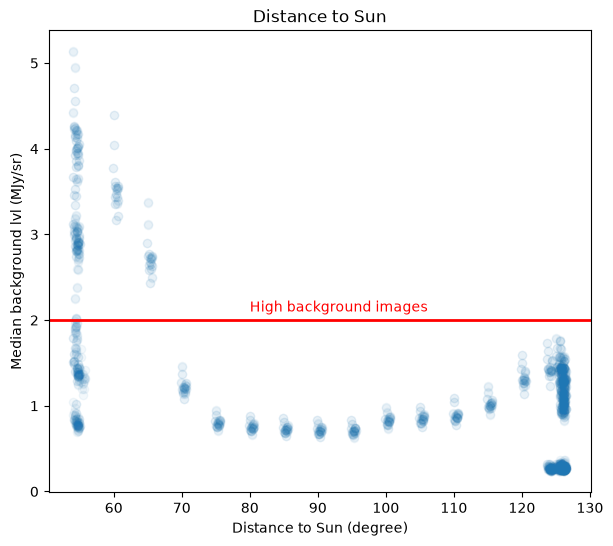

In [40]:
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(d_sun, CAR170_db["image_median"], alpha=0.05)
ax.axhline(2, linewidth=2, color="red")
ax.text(80, 2.1, "High background images", color="red")
ax.set_ylabel("Median background lvl (MJy/sr)")
ax.set_xlabel("Distance to Sun (degree)")
ax.set_title("Distance to Sun")
plt.savefig("back_vs_sun.png", dpi=300)

In [8]:
highback_db = CAR170_db[CAR170_db["image_median"] > 2]

In [9]:
string_array = np.array(highback_db["fileSetName"])
np.savetxt("highback_CAR170.txt", string_array, fmt="%s", encoding="utf-8")

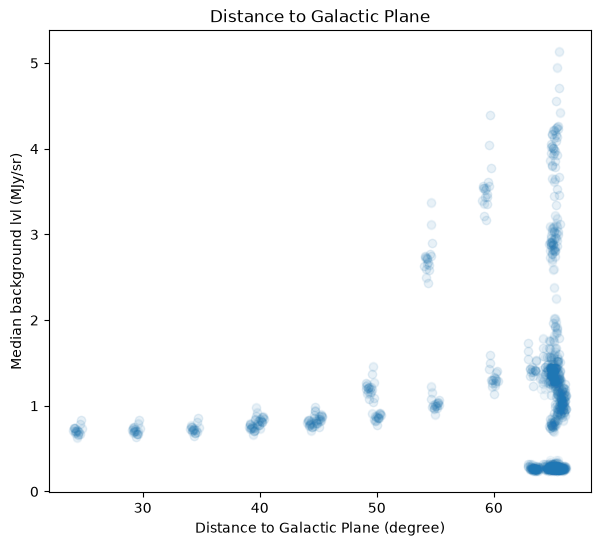

In [38]:
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(d_MW,  CAR170_db["image_median"], alpha=0.05)
ax.set_ylabel("Median background lvl (MJy/sr)")
ax.set_xlabel("Distance to Galactic Plane (degree)")
ax.set_title("Distance to Galactic Plane")
plt.savefig("back_vs_MW.png", dpi=300)

In [35]:
import zodipy

wavelength = np.array([1,1.5,2])
weights = np.array([0.5,1,0.5])

zody_MJysr = np.zeros(len(CAR170_db["ra"]))
for i in tqdm(range(len(zody_MJysr))):
    ra = [np.array(CAR170_db["ra"][i])]
    dec = [np.array(CAR170_db["dec"][i])]
    mjd = [np.array(CAR170_db["mjd"][i])]
    obspos = [CAR170_db["spatial_x"][i], CAR170_db["spatial_y"][i], CAR170_db["spatial_z"][i]]*u.km
    skycoord = SkyCoord(ra, dec, unit="degree", frame="icrs")
    # Note that we manually set the obstime attribute
    skycoord.obstime = Time(mjd, format='mjd', scale='utc')
    # Initialize a zodiacal light model at a wavelength/frequency or over a bandpass
    model = zodipy.Model(wavelength*u.micron, weights=weights, extrapolate=True)
    zody_MJysr[i] = model.evaluate(skycoord, obspos=obspos)[0].value

100%|██████████| 1890/1890 [00:36<00:00, 51.15it/s]


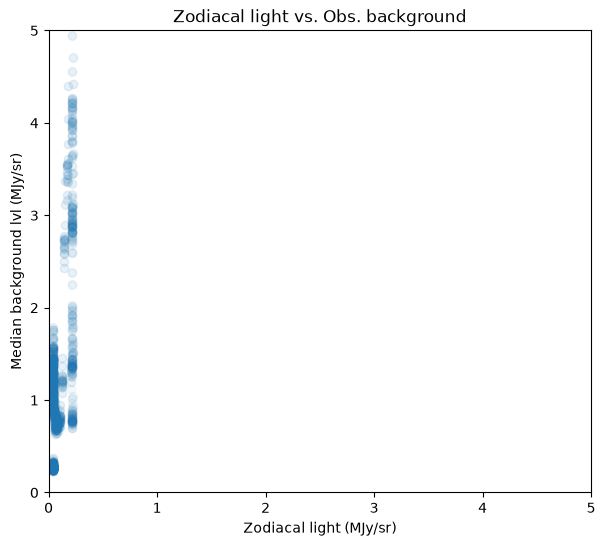

In [41]:
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(zody_MJysr, CAR170_db["image_median"], alpha=0.05)
ax.set_ylabel("Median background lvl (MJy/sr)")
ax.set_xlabel("Zodiacal light (MJy/sr)")
ax.set_xlim(0,5)
ax.set_ylim(0,5)
ax.set_title("Zodiacal light vs. Obs. background")
plt.savefig("back_vs_zodiacal.png", dpi=300)

In [26]:
zody_MJysr

array([0., 0., 0., ..., 0., 0., 0.], shape=(1890,))

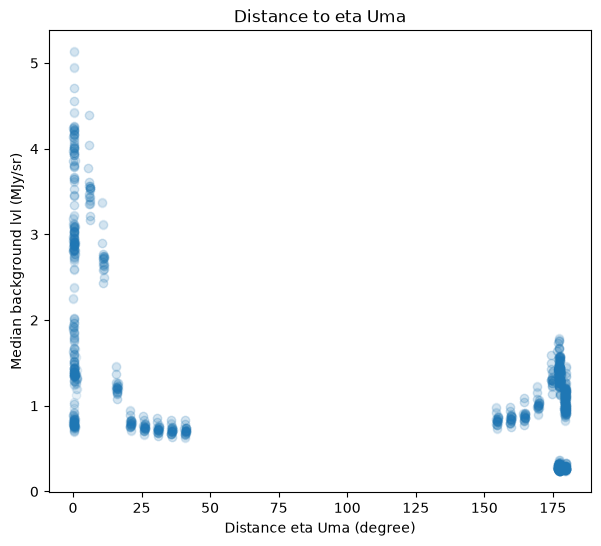

In [42]:
etaUma = SkyCoord(206.8868780*u.degree, +49.3079421*u.degree, frame="icrs")
CAR170_point = SkyCoord(CAR170_db["ra"]*u.degree, CAR170_db["dec"]*u.degree, frame="icrs")

dist_etaUma = etaUma.separation(CAR170_point)

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(dist_etaUma.degree, CAR170_db["image_median"], alpha=0.1)
ax.set_ylabel("Median background lvl (MJy/sr)")
ax.set_xlabel("Distance eta Uma (degree)")
ax.set_title("Distance to eta Uma")
plt.savefig("back_vs_etauma.png", dpi=300)

In [32]:
ra=np.array(CAR170_db["ra"][0:10])
dec=np.array(CAR170_db["dec"][0:10])
expstart=np.array(CAR170_db["mjd"][0])
obspos="earth"
wavelength = np.array([0.4,0.5,0.6])+0.5
weights = np.array([0.1,1,0.1])
# Use Astropy's `SkyCoord` object to specify coordinates
skycoord = SkyCoord(ra, dec, unit="degree", frame="icrs")
# Note that we manually set the obstime attribute
skycoord.obstime = Time(expstart, format='mjd', scale='utc')


#print("Zodipy wave:")
#print(wavelength)
# Initialize a zodiacal light model at a wavelength/frequency or over a bandpass
model = zodipy.Model(wavelength*u.micron, weights=weights, extrapolate=True)
emission = model.evaluate(skycoord, obspos="earth")
print(emission.value)

[0.1325343  0.13267253 0.13279687 0.13263    0.13276883 0.13289304
 0.13268978 0.13282945 0.13295366 0.13241376]


In [19]:
len(expstart)

TypeError: len() of unsized object

In [ ]:
sso_bodies

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(ra_target, dec_target)

In [ ]:
plt.scatter(ra_target, median_back)

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time

import zodipy

# Initialize a zodiacal light model at a wavelength/frequency or over a bandpass
model = zodipy.Model(1.5 * u.micron)

# Use Astropy's `SkyCoord` object to specify coordinates
lon = [10, 10.1, 10.2] * u.deg
lat = [90, 89, 88] * u.deg
obstimes = Time(["2022-01-01 12:00:00", "2022-01-01 12:01:00", "2022-01-01 12:02:00"])
skycoord = SkyCoord(lon, lat, obstime=obstimes, frame="galactic")

# Evaluate the zodiacal light model
emission = model.evaluate(skycoord)

print(emission)
# > [27.52410841 27.66572294 27.81251906] MJy / sr

In [ ]:
stream["meta"].keys()

In [ ]:
results

In [ ]:
roman_exposure = rs.core.exposure(products)

In [ ]:
roman_exposure.save_drz(outname=exposures[0] + ".fits", resolution=0.11)
roman_exposure.straylight()


In [ ]:
roman_exposure.SCIEXTS

In [ ]:
roman_exposure.make_close_stars_ds9_region()

## About this Notebook

**Author:** Alejandro S. Borlaff - NASA Ames Research Center (Code S) - a.s.borlaff@nasa.gov 

**Updated on** September 20, 2026. 